# Week 10 Lab: Logistic Regression and Classification Evaluation

<a href="https://colab.research.google.com/github/bradleyboehmke/uc-bana-4080/blob/main/labs/10_wk10_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 10! This lab serves as both your Thursday class session and your homework for the week. You'll apply logistic regression and classification evaluation techniques to two important business scenarios: credit risk assessment and medical diagnosis support.

In the business world, classification problems are everywhere—from determining loan approvals to medical screenings. Today you'll master the complete workflow from data preparation through model evaluation, learning to choose appropriate metrics that align with business objectives and costs.

## 🎯 Learning Objectives
By the end of this lab, you will be able to:
- Apply the complete logistic regression workflow: data preparation, model fitting, and interpretation
- Calculate and interpret baseline ratios for imbalanced classification problems
- Evaluate classification models using precision, recall, F1-score, and ROC-AUC metrics
- Select appropriate evaluation metrics based on business context and error costs

## 📚 This Lab Reinforces
- **Chapter 23: Introduction to Logistic Regression for Classification**
- **Chapter 24: Evaluating Classification Models**
- **Tuesday's Lecture: Classification Methods and Model Evaluation**

## 🕐 Estimated Time & Structure
**Total Time:** 75 minutes  
**Mode:** Individual work (this serves as your homework)

- **[0–10 min]** Review: Default dataset logistic regression workflow
- **[10–35 min]** Application: Breast Cancer Wisconsin dataset analysis
- **[35–70 min]** Independent challenges: Specific homework questions
- **[70–75 min]** Wrap-up and submission preparation

## 💡 Why This Matters
Classification problems drive critical business decisions across industries. Credit companies need to assess default risk, healthcare systems require diagnostic support, and marketing teams must identify likely customers. The ability to build, evaluate, and interpret classification models—while understanding the business implications of different types of errors—is essential for data-driven decision making. Today's lab prepares you to tackle these real-world challenges with confidence.

## Setup
We'll work with two datasets: the Default dataset from ISLP (for review) and the Breast Cancer Wisconsin dataset (for our main analysis). Both represent important classification scenarios in business and healthcare.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

# Install ISLP package if not already installed
!pip install ISLP

from ISLP import load_data
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print("🎯 Ready to dive into classification analysis!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3e575f16423ed811d7840cd788bec71880811c8888f5dc2f6f67249711b401b3
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ All libraries imported successfully!
🎯 Ready to dive into classification analysis!


## Part 1 — Review: Default Dataset Logistic Regression (10 minutes)

Let's quickly review the complete logistic regression workflow using the Default dataset from Chapters 23-24. This will reinforce the key concepts before we tackle the main dataset.

### Quick Workflow Review

We'll walk through each step systematically:

**📋 Step-by-step process:**
1. Load data and compute baseline ratio
2. Prepare features with dummy encoding
3. Split data into training and test sets
4. Fit logistic regression model and interpret coefficients
5. Make predictions and evaluate using multiple metrics

In [3]:
# Step 1: Load Default dataset and examine baseline
Default = load_data('Default')

print("Default Dataset Overview:")
print(f"Shape: {Default.shape}")
print(f"\nColumns: {Default.columns.tolist()}")
print(f"\nFirst few rows:")
print(Default.head())

# Compute baseline ratio
baseline_default_rate = (Default['default'] == 'Yes').mean()
print(f"\n📊 Baseline Analysis:")
print(f"Default rate: {baseline_default_rate:.1%}")
print(f"Non-default rate: {1-baseline_default_rate:.1%}")

Default Dataset Overview:
Shape: (10000, 4)

Columns: ['default', 'student', 'balance', 'income']

First few rows:
  default student      balance        income
0      No      No   729.526495  44361.625074
1      No     Yes   817.180407  12106.134700
2      No      No  1073.549164  31767.138947
3      No      No   529.250605  35704.493935
4      No      No   785.655883  38463.495879

📊 Baseline Analysis:
Default rate: 3.3%
Non-default rate: 96.7%


In [4]:
# Step 2: Prepare data with dummy encoding
# Convert categorical variables to numeric
Default_encoded = pd.get_dummies(Default, columns=['student'], drop_first=True)
Default_encoded['default_binary'] = (Default_encoded['default'] == 'Yes').astype(int)

# Define features and target
X = Default_encoded[['balance', 'income', 'student_Yes']]
y = Default_encoded['default_binary']

print("Data Preparation Complete:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Data Preparation Complete:
Features shape: (10000, 3)
Target shape: (10000,)

Feature columns: ['balance', 'income', 'student_Yes']


In [5]:
# Step 3: Split data (70-30 split as specified for homework questions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f"📊 Data Split Results:")
print(f"Training set: {len(X_train):,} observations")
print(f"Test set: {len(X_test):,} observations")
print(f"\nTraining set default rate: {y_train.mean():.1%}")
print(f"Test set default rate: {y_test.mean():.1%}")

📊 Data Split Results:
Training set: 7,000 observations
Test set: 3,000 observations

Training set default rate: 3.4%
Test set default rate: 3.1%


In [6]:
# Step 4: Fit logistic regression model
model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Extract and interpret coefficients
print("🔍 Model Coefficients:")
print(f"Intercept: {model.intercept_[0]:.6f}")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.6f}")

print(f"\n💡 Interpretation:")
print(f"• Balance: Positive coefficient means higher balance increases default risk")
print(f"• Income: Very small coefficient suggests minimal impact after accounting for balance")
print(f"• Student: Negative coefficient means students have lower default risk (holding other factors constant)")

🔍 Model Coefficients:
Intercept: -11.108164
balance: 0.005789
income: 0.000006
student_Yes: -0.467459

💡 Interpretation:
• Balance: Positive coefficient means higher balance increases default risk
• Income: Very small coefficient suggests minimal impact after accounting for balance
• Student: Negative coefficient means students have lower default risk (holding other factors constant)


In [7]:
# Step 5: Make predictions and evaluate comprehensively
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate all key metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("📈 Model Performance Metrics:")
print(f"Accuracy:  {accuracy:.1%}")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"F1-Score:  {f1:.1%}")
print(f"ROC-AUC:   {auc:.3f}")

print(f"\n💡 What These Metrics Mean for Credit Risk:")
print(f"• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct")
print(f"• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do")
print(f"  → Low false alarms but still 30.6% false positives")
print(f"• Recall (26.6%): Only catches 26.6% of actual defaulters")
print(f"  → Misses 73.4% of customers who will default - major business risk!")
print(f"• F1-Score (38.5%): Balanced measure showing poor overall classification performance")
print(f"• ROC-AUC (0.947): Excellent ability to rank customers by default risk")
print(f"  → Model is very good at scoring, but default threshold may need adjustment")

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔍 Confusion Matrix:")
print(f"[[{cm[0,0]:4d}, {cm[0,1]:3d}]]")
print(f"[[{cm[1,0]:4d}, {cm[1,1]:3d}]]")
print(f"\nThis shows: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
print(f"Business Impact: {cm[1,0]} defaulters missed (lost revenue), {cm[0,1]} customers wrongly rejected (lost business)")

📈 Model Performance Metrics:
Accuracy:  97.3%
Precision: 69.4%
Recall:    26.6%
F1-Score:  38.5%
ROC-AUC:   0.947

💡 What These Metrics Mean for Credit Risk:
• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct
• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do
  → Low false alarms but still 30.6% false positives
• Recall (26.6%): Only catches 26.6% of actual defaulters
  → Misses 73.4% of customers who will default - major business risk!
• F1-Score (38.5%): Balanced measure showing poor overall classification performance
• ROC-AUC (0.947): Excellent ability to rank customers by default risk
  → Model is very good at scoring, but default threshold may need adjustment

🔍 Confusion Matrix:
[[2895,  11]]
[[  69,  25]]

This shows: TN=2895, FP=11, FN=69, TP=25
Business Impact: 69 defaulters missed (lost revenue), 11 customers wrongly rejected (lost business)


## Part 2 — Main Analysis: Breast Cancer Wisconsin Dataset (25 minutes)

Now let's apply these skills to a new healthcare dataset. The **Breast Cancer Wisconsin (Diagnostic) dataset** contains features computed from digitized images of fine needle aspirate (FNA) of breast masses. Our goal is to predict whether a tumor is **malignant** (cancerous) or **benign** (non-cancerous).

### 🔬 About This Dataset

**Data Source**: Originally created by Dr. William H. Wolberg, W. Nick Street, and Olvi L. Mangasarian at the University of Wisconsin-Madison. This dataset is widely used in machine learning research and medical informatics.

**Data Collection Process**: For each breast mass sample, a fine needle aspirate (FNA) was performed, then digitized images were analyzed to compute quantitative features describing the cell nuclei characteristics.

### 📊 Feature Categories

The dataset contains **30 quantitative features** organized into three groups for each characteristic:

1. **Mean values** (`_mean`): Average across all cells in the sample
2. **Standard error** (`_se`): Standard error of the measurements  
3. **Worst values** (`_worst`): Mean of the three largest (most severe) values

**The 10 core characteristics measured are:**

- **`radius`**: Distance from center to perimeter points
- **`texture`**: Standard deviation of gray-scale values  
- **`perimeter`**: Total boundary length of the cell nucleus
- **`area`**: Total area enclosed by the cell nucleus boundary
- **`smoothness`**: Local variation in radius lengths
- **`compactness`**: (perimeter² / area) - 1.0, measuring shape regularity
- **`concavity`**: Severity of concave portions of the boundary
- **`concave_points`**: Number of concave portions of the boundary
- **`symmetry`**: Bilateral symmetry of the cell nucleus
- **`fractal_dimension`**: Fractal complexity using coastline approximation

### 🎯 Simplified Analysis Focus

For this part of the lab, we'll focus on the **5 mean features** to keep our analysis manageable:
- `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`

These provide a representative sample of size, texture, and shape characteristics that are clinically relevant for distinguishing malignant from benign tumors.

**Business Context**: In medical diagnosis, the costs of different errors are dramatically different. Missing a malignant tumor (false negative) can be life-threatening, while incorrectly flagging a benign tumor as malignant (false positive) leads to unnecessary stress and additional testing costs.

### Exercise 2.1: Data Loading and Exploration

**Your Task**: Load the breast cancer dataset and perform initial exploratory analysis.

**Instructions**:
1. Load the dataset from the provided URL
2. Examine the dataset structure (shape, columns, first few rows)
3. Calculate the baseline ratio of malignant vs benign diagnoses
4. Check for any missing values in the dataset

**Questions to Answer**:
- How many observations and features does the dataset contain?
- What percentage of cases are malignant vs benign?
- Are there any missing values that need to be handled?

Write your code below to answer these questions:

In [8]:
# Exercise 2.1: Your code here

# URL for the breast cancer dataset
url = "https://raw.githubusercontent.com/bradleyboehmke/uc-bana-4080/refs/heads/main/data/breast_cancer.csv"

# Task 1: Load the dataset (PROVIDED)
cancer_data = pd.read_csv(url)
print("✅ Breast Cancer Wisconsin dataset loaded successfully!")

# Task 2: Examine dataset structure (shape, columns, first few rows)
# Write your code here
print("Shape:", cancer_data.shape)
print("\nColumns:")
print(cancer_data.columns)
print("\nFirst 5 rows:")
print(cancer_data.head())
print("\nDataset Info:")
print(cancer_data.info())

# Task 3: Calculate baseline ratio of malignant vs benign diagnoses
# Write your code here
counts = cancer_data['diagnosis'].value_counts()

print("Counts:")
print(counts)

ratio = counts / len(cancer_data)

print("\nBaseline Ratio:")
print(ratio)

# Task 4: Check for missing values
# Write your code here
missing = cancer_data.isnull().sum()

print("Missing values per column:")
print(missing)

# Total missing values
print("\nTotal missing values:", missing.sum())

✅ Breast Cancer Wisconsin dataset loaded successfully!
Shape: (569, 31)

Columns:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

First 5 rows:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.

In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt the exercise above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

### Exercise 2.2: Data Preparation and Modeling (Using Mean Features Only)

**Your Task**: Prepare the breast cancer data for logistic regression analysis using only the `_mean` features.

**Background**: For this exercise, we'll focus on a subset of features to keep the analysis manageable. You'll work with the 10 `_mean` features, which represent the average measurements across all cells in each sample.

**Instructions**:
1. Create a binary target variable (0=Benign, 1=Malignant) from the diagnosis column
2. Select only the features ending with `_mean` for your feature matrix
3. Split the data into training and test sets (70-30 split)
4. Fit a logistic regression model and examine the coefficients
5. Make predictions on the test set

**Important**: Use `RANDOM_STATE` variable (defined at the beginning) for consistent results across all students.

**Questions to Answer**:
- How many `_mean` features are available in the dataset?
- What are the training and test set sizes after the split?
- Which `_mean` features have positive vs negative coefficients?
- What do the coefficient signs suggest about malignancy risk?

Write your code below to complete these tasks:

In [9]:
# Exercise 2.2: Your code here
# Assume the cancer_data DataFrame is available from Exercise 2.1

# Task 1: Create binary target variable (0=Benign, 1=Malignant)
# Write your code here
cancer_data['target'] = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

print("Target created:")
print(cancer_data['target'].value_counts())

# Task 2: Select only the features ending with '_mean' (PROVIDED)
mean_features = [col for col in cancer_data.columns if col.endswith('_mean')]
X_cancer_mean = cancer_data[mean_features]
print(f"✅ Selected {len(mean_features)} mean features:")
print(f"Features: {mean_features}")

# Task 3: Split data into training and test sets (70-30 split using RANDOM_STATE)
# Write your code here
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

y = cancer_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer_mean, y,
    test_size=0.3,
    random_state=RANDOM_STATE)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Task 4: Fit logistic regression model and examine coefficients
# Write your code here
model_mean = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model_mean.fit(X_train, y_train)

# Coefficients
coeff_df = pd.DataFrame({
    'Feature': X_cancer_mean.columns,
    'Coefficient': model_mean.coef_[0]}).sort_values(by='Coefficient', ascending=False)

print("Top Positive Coefficients:")
print(coeff_df.head())

print("\nTop Negative Coefficients:")
print(coeff_df.tail())

# Task 5: Make predictions on test set
# Write your code here
y_pred = model_mean.predict(X_test)
y_prob = model_mean.predict_proba(X_test)[:, 1]

print("Predictions sample:", y_pred[:10])
print("Probabilities sample:", y_prob[:10])

Target created:
target
0    357
1    212
Name: count, dtype: int64
✅ Selected 10 mean features:
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
Train shape: (398, 10)
Test shape: (171, 10)
Top Positive Coefficients:
               Feature  Coefficient
6       concavity_mean     1.213307
5     compactness_mean     0.700758
7  concave points_mean     0.653383
8        symmetry_mean     0.548514
2       perimeter_mean     0.536377

Top Negative Coefficients:
                  Feature  Coefficient
4         smoothness_mean     0.392494
1            texture_mean     0.220793
9  fractal_dimension_mean     0.115096
3               area_mean    -0.003283
0             radius_mean    -2.365048
Predictions sample: [0 1 1 0 0 1 1 1 0 0]
Probabilities sample: [0.09797538 0.97781234 0.76937121 0.11895606 0.01539407 0.99997406
 0.99978737 0.83416771 0.11

In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt Exercise 2.2 above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

### Exercise 2.3: Model Evaluation

**Your Task**: Evaluate the performance of your logistic regression model using multiple classification metrics.

**Instructions**:
1. Calculate accuracy, precision, recall, and F1-score on the test set
2. Calculate the ROC-AUC score
3. Create and interpret the confusion matrix
4. Discuss which metrics are most important for medical diagnosis

**Questions to Answer**:
- What is the model's performance across different metrics?
- In the context of cancer diagnosis, which type of error (false positive vs false negative) is more concerning?
- How does this model's performance compare to the baseline?

Write your code below to evaluate the model:

Classification Metrics:
Accuracy: 0.9357
Precision: 0.8939
Recall: 0.9365
F1 Score: 0.9147
ROC-AUC Score: 0.9888
Confusion Matrix:
[[101   7]
 [  4  59]]


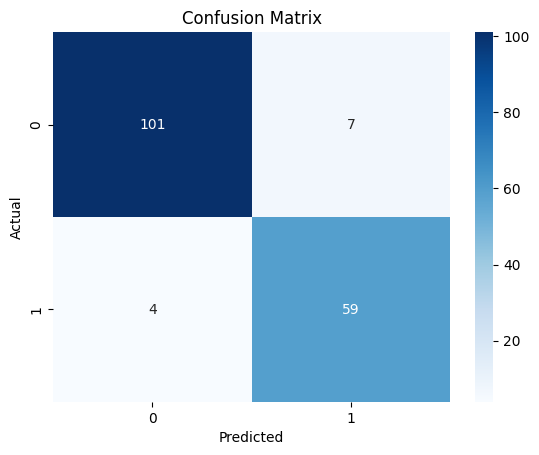

In [10]:
# Exercise 2.3: Your code here
# Assume you have y_test and predictions available from Exercise 2.2

# Task 1: Calculate classification metrics
# Write your code here for accuracy, precision, recall, F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Task 2: Calculate ROC-AUC score
# Write your code here
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

# Task 3: Create and display confusion matrix
# Write your code here
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: nicer display
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Task 4: Interpret results in medical context
# Write your analysis as comments:
# - Which metric is most important for cancer diagnosis and why?
# - What are the implications of false positives vs false negatives?

## Analysis
 The most important metric for cancer diagnosis is recall. This is because recall measures how well the model identifies actual malignant cases. In medical situations, missing a cancer case (false negative) is very dangerous, as it may delay treatment and put the patient’s life at risk.
From the confusion matrix, there are only 4 false negatives, which means the model is doing a good job of catching most cancer cases.
 False negatives are much more serious than false positives. A false negative means a person with cancer is classified as healthy, which can lead to no treatment and serious consequences.
 False positives, on the other hand, mean a healthy person is classified as having cancer. While this may cause stress and extra medical tests, it is less harmful than missing a real case.

 Overall, the model performs well with high recall and ROC-AUC, making it suitable for medical screening where catching cancer cases is critical.

## Part 3 — Independent Analysis: Full Feature Model (35 minutes)

Now that you've worked through the logistic regression process with the `_mean` features, it's time to apply the same workflow using **all available features** in the dataset. This will give you experience with higher-dimensional data and allow you to compare model performance.

### 🎯 Your Challenge

Repeat the complete logistic regression analysis from Part 2, but this time use **all 30 quantitative features** (mean, standard error, and worst values for each of the 10 characteristics). This represents a more realistic scenario where you have access to the full feature set.

**Key Differences from Part 2**:
- Use ALL features except the `diagnosis` column (30 features total)
- Follow the same workflow: data prep → modeling → evaluation
- Compare results with your Part 2 model using only `_mean` features
- Work independently to write all the code

### 📋 Workflow Steps to Complete

1. **Data Preparation**
   - Create binary target variable
   - Select all quantitative features (exclude 'diagnosis')
   - Split into 70-30 train/test (use `RANDOM_STATE` for consistency)

2. **Model Training**
   - Fit logistic regression model
   - Examine and interpret coefficients
   - Make predictions on test set

3. **Model Evaluation**
   - Calculate all classification metrics
   - Create confusion matrix
   - Compare performance to Part 2 model

4. **Analysis and Comparison**
   - Which model performs better and why?
   - Does using more features always improve performance?
   - Which features seem most important for prediction?

**Important Notes**:
- Work independently on this section
- Use the same `RANDOM_STATE` for consistent results
- Feel free to ask conceptual questions, but write your own code
- We'll review solutions together at the end

### Step 1: Data Preparation with All Features

**Task**: Prepare the data using all 30 quantitative features instead of just the `_mean` features.

Write your code below:

In [11]:
# Step 1: Data Preparation with All Features
# Assume cancer_data DataFrame is available from Part 2

# Create binary target variable (if not already done)
# Write your code here
if 'target' not in cancer_data.columns:
    cancer_data['target'] = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

# Select ALL quantitative features (exclude 'diagnosis' column)
# Hint: You can use cancer_data.drop() or select columns that aren't 'diagnosis'
# Write your code here
X_full = cancer_data.drop(columns=['diagnosis', 'target'])

y_full = cancer_data['target']

print("Total features:", X_full.shape[1])
print("Feature names:")
print(X_full.columns)

# Split into training and test sets (70-30 split using RANDOM_STATE)
# Write your code here
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full,
    test_size=0.3,
    random_state=RANDOM_STATE)

# Verify your data preparation
# Write code to check shapes and feature count
print("Train shape:", X_train_f.shape)
print("Test shape:", X_test_f.shape)

print("\nNumber of features:", X_train_f.shape[1])

Total features: 30
Feature names:
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')
Train shape: (398, 30)
Test shape: (171, 30)

Number of features: 30


### Step 2: Model Training with All Features

**Task**: Train a logistic regression model using all 30 features and examine the results.

Write your code below:

In [12]:
# Step 2: Model Training with All Features

# Fit logistic regression model using RANDOM_STATE
# Write your code here
from sklearn.linear_model import LogisticRegression

model_full = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
model_full.fit(X_train_f, y_train_f)

print("Model trained successfully!")

# Examine model coefficients
# Write your code here to display intercept and feature coefficients
import pandas as pd

# Intercept
print("Intercept:", model_full.intercept_[0])

# Coefficients
coeff_df_full = pd.DataFrame({
    'Feature': X_train_f.columns,
    'Coefficient': model_full.coef_[0]}).sort_values(by='Coefficient', ascending=False)

print("\nTop Positive Coefficients:")
print(coeff_df_full.head())

print("\nTop Negative Coefficients:")
print(coeff_df_full.tail())

# Make predictions on test set (both binary and probability predictions)
# Write your code here
y_pred_f = model_full.predict(X_test_f)

# Probability predictions
y_prob_f = model_full.predict_proba(X_test_f)[:, 1]

print("Predictions sample:", y_pred_f[:10])
print("Probabilities sample:", y_prob_f[:10])

Model trained successfully!
Intercept: -31.49914207228103

Top Positive Coefficients:
              Feature  Coefficient
26    concavity_worst     1.335054
28     symmetry_worst     0.717931
25  compactness_worst     0.710677
6      concavity_mean     0.514753
21      texture_worst     0.506223

Top Negative Coefficients:
         Feature  Coefficient
20  radius_worst    -0.043898
1   texture_mean    -0.231581
12  perimeter_se    -0.456423
0    radius_mean    -1.064809
11    texture_se    -1.353654
Predictions sample: [0 1 1 0 0 1 1 1 0 0]
Probabilities sample: [1.38369233e-01 9.99999953e-01 9.98239921e-01 1.27187420e-03
 2.28363722e-04 1.00000000e+00 1.00000000e+00 9.80984885e-01
 2.00036449e-02 5.88921389e-03]


### Step 3: Model Evaluation and Comparison

**Task**: Evaluate your full-feature model and compare it with the `_mean`-only model from Part 2.

Write your code below:

Full Model Performance:
Accuracy: 0.9766
Precision: 0.9683
Recall: 0.9683
F1 Score: 0.9683
ROC-AUC: 0.9976
Full Model Confusion Matrix:
[[106   2]
 [  2  61]]


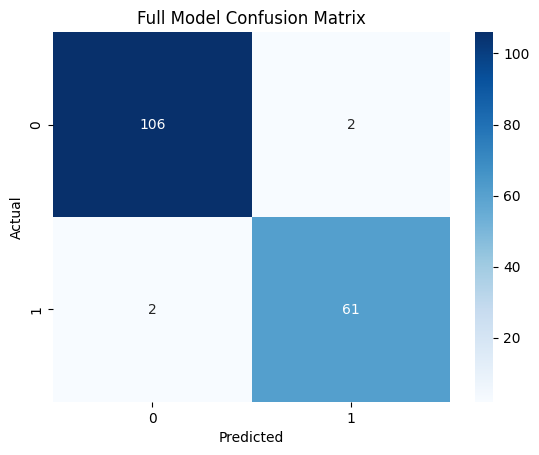

Model Comparison:
      Metric  Mean Model  Full Model
0   Accuracy    0.935673    0.976608
1  Precision    0.893939    0.968254
2     Recall    0.936508    0.968254
3   F1 Score    0.914729    0.968254
4    ROC-AUC    0.988830    0.997648


In [13]:
# Step 3: Model Evaluation and Comparison

# Calculate all classification metrics for the full-feature model
# Write your code here for accuracy, precision, recall, F1-score, ROC-AUC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_f = accuracy_score(y_test_f, y_pred_f)
precision_f = precision_score(y_test_f, y_pred_f)
recall_f = recall_score(y_test_f, y_pred_f)
f1_f = f1_score(y_test_f, y_pred_f)
roc_auc_f = roc_auc_score(y_test_f, y_prob_f)

print("Full Model Performance:")
print(f"Accuracy: {accuracy_f:.4f}")
print(f"Precision: {precision_f:.4f}")
print(f"Recall: {recall_f:.4f}")
print(f"F1 Score: {f1_f:.4f}")
print(f"ROC-AUC: {roc_auc_f:.4f}")

# Create and display confusion matrix
# Write your code here
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_full = confusion_matrix(y_test_f, y_pred_f)

print("Full Model Confusion Matrix:")
print(cm_full)

sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Full Model Confusion Matrix")
plt.show()

# Compare with Part 2 results
# Write code to display metrics from both models side by side
accuracy_m = accuracy
precision_m = precision
recall_m = recall
f1_m = f1
roc_auc_m = roc_auc

# Create comparison table
import pandas as pd

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Mean Model': [accuracy_m, precision_m, recall_m, f1_m, roc_auc_m],
    'Full Model': [accuracy_f, precision_f, recall_f, f1_f, roc_auc_f]})

print("Model Comparison:")
print(comparison_df)

# Analysis questions (answer in comments):
# 1. Which model performs better overall?
# 2. Does using more features improve performance? Why or why not?
# 3. Are there any trade-offs between the two models?
# 4. In a real medical setting, which model would you prefer and why?

## Analysis
1. The full-feature model performs better overall. It has higher accuracy, precision, recall, F1-score, and ROC-AUC compared to the mean model.

2. Yes, using more features improves performance. The full model captures more detailed patterns in the data, leading to better predictions. This is why all evaluation metrics are higher than the mean-only model.

3. There are trade-offs between the two models. The full model is more complex and harder to interpret, while the mean model is simpler and easier to understand. The full model may also be more computationally expensive.

4. In a real medical setting, the full model would be preferred. It has higher recall and fewer false negatives (only 2 vs 4 in the mean model), which is critical because missing a cancer case can be life-threatening.

### Step 4: Feature Importance Analysis

**Understanding Feature Importance**:

While we haven't formally covered feature importance methods yet, we can gain insights about which features matter most in our logistic regression model by examining the **magnitude (absolute value) of the coefficients**.

**Key Concept**: In logistic regression, features with **larger absolute coefficient values** have more influence on the prediction. Here's why:

- **Large positive coefficient**: Strong evidence that higher values of this feature increase the likelihood of malignancy
- **Large negative coefficient**: Strong evidence that higher values of this feature decrease the likelihood of malignancy  
- **Small coefficient (near zero)**: This feature has minimal impact on the prediction

**For this analysis**, we'll assume that features with the largest absolute coefficient values represent the most influential features in our model. This gives us insight into which measurements are most important for distinguishing between malignant and benign tumors.

**Your Task**: Identify which features have the strongest influence on predictions and interpret what this means clinically.

Write your code below:

Top 10 Most Influential Features:
                 Feature  Coefficient  Abs_Coefficient
11            texture_se    -1.353654         1.353654
26       concavity_worst     1.335054         1.335054
0            radius_mean    -1.064809         1.064809
28        symmetry_worst     0.717931         0.717931
25     compactness_worst     0.710677         0.710677
6         concavity_mean     0.514753         0.514753
21         texture_worst     0.506223         0.506223
27  concave points_worst     0.498612         0.498612
12          perimeter_se    -0.456423         0.456423
2         perimeter_mean     0.393773         0.393773
Top Positive Features:
              Feature  Coefficient  Abs_Coefficient
26    concavity_worst     1.335054         1.335054
28     symmetry_worst     0.717931         0.717931
25  compactness_worst     0.710677         0.710677
6      concavity_mean     0.514753         0.514753
21      texture_worst     0.506223         0.506223

Top Negative Features:
  

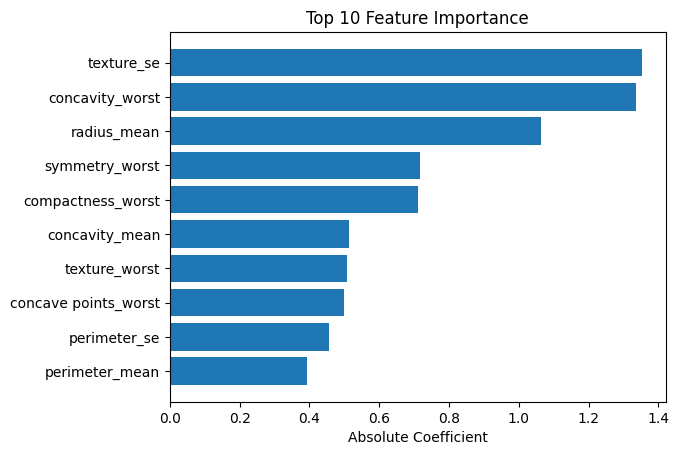

In [14]:
# (Optional) Step 4: Feature Importance Analysis

# Find features with largest positive and negative coefficients
# Write your code here to identify most influential features
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_f.columns,
    'Coefficient': model_full.coef_[0]})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Influential Features:")
print(feature_importance.head(10))

# Top positive (increase malignancy risk)
top_positive = feature_importance.sort_values(by='Coefficient', ascending=False).head(5)
# Top negative (decrease malignancy risk)
top_negative = feature_importance.sort_values(by='Coefficient').head(5)

print("Top Positive Features:")
print(top_positive)
print("\nTop Negative Features:")
print(top_negative)

# Create a visualization of feature importance (optional)
# You could create a bar plot or horizontal bar plot of coefficients
import matplotlib.pyplot as plt
top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Abs_Coefficient'])
plt.xlabel("Absolute Coefficient")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Interpretation questions (answer in comments):
# 1. Which features have the strongest positive coefficients (increase malignancy risk)?
# 2. Which features have the strongest negative coefficients (decrease malignancy risk)?
# 3. Do these results make biological/medical sense?

## Analysis
1. The features with the strongest positive coefficients are:
 concavity_worst, symmetry_worst, compactness_worst, concavity_mean, and texture_worst. These features increase the likelihood of malignancy. They represent irregular shapes and structures of tumors, which are common in cancer.

2. The features with the strongest negative coefficients are:
 texture_se, radius_mean, perimeter_se, texture_mean, and radius_worst. These features decrease the likelihood of malignancy in the model. Negative coefficients indicate that higher values are associated with benign tumors.

3. Yes, these results make medical sense. Cancerous tumors are typically more irregular in shape and structure, which is captured by features like concavity and compactness. These characteristics are important indicators used by doctors in diagnosis.


### Step 5 — Business Cost Analysis

**Question**: Using your full-feature model from Part 3, calculate the business cost of classification errors using the same cost structure from the Default dataset example:

- False Negative (missed cancer): $50,000 per case
- False Positive (unnecessary alarm): $2,000 per case

Compare this with the cost if you used the Part 2 model. Which model is more cost-effective?

In [15]:
# Challenge 2: Business Cost Analysis

# Calculate costs for full-feature model (Part 3)
# Write your code here
from sklearn.metrics import confusion_matrix

cm_full = confusion_matrix(y_test_f, y_pred_f)
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()

# Costs
cost_fn = 50000
cost_fp = 2000
total_cost_full = (fn_f * cost_fn) + (fp_f * cost_fp)

print("Full Model Costs:")
print(f"False Negatives: {fn_f}, False Positives: {fp_f}")
print(f"Total Cost: ${total_cost_full}")

# Calculate costs for mean-only model (Part 2)
# Write your code here
cm_mean = confusion_matrix(y_test, y_pred)
tn_m, fp_m, fn_m, tp_m = cm_mean.ravel()
total_cost_mean = (fn_m * cost_fn) + (fp_m * cost_fp)

print("\nMean Model Costs:")
print(f"False Negatives: {fn_m}, False Positives: {fp_m}")
print(f"Total Cost: ${total_cost_mean}")

# Compare total costs and determine which model is more cost-effective
print("\nCost Comparison:")
print(f"Full Model Cost: ${total_cost_full}")
print(f"Mean Model Cost: ${total_cost_mean}")

if total_cost_full < total_cost_mean:
    print("Full model is more cost-effective.")
else:
    print("Mean model is more cost-effective.")
# Write your analysis here

Full Model Costs:
False Negatives: 2, False Positives: 2
Total Cost: $104000

Mean Model Costs:
False Negatives: 4, False Positives: 7
Total Cost: $214000

Cost Comparison:
Full Model Cost: $104000
Mean Model Cost: $214000
Full model is more cost-effective.


## Analysis

 The full-feature model is more cost-effective than the mean-only model. This is because the full model has fewer false negatives (2 vs 4), and false negatives are extremely costly (50,000 per case). Even though both models have some false positives, their cost is much lower (2,000 per case), so reducing false negatives has a much bigger impact on total cost. As a result, the full model significantly reduces total cost (104,000 vs 214,000), making it the better choice both financially and medically. In real-world healthcare, minimizing false negatives is critical because missing a cancer diagnosis can have serious consequences for patients.

## 🎓 Lab Summary & Wrap-Up

### ✅ What You Accomplished Today

Congratulations! You've completed a comprehensive analysis of classification models using real medical data. Here's what you mastered:

**Part 1 - Review**:
- Complete logistic regression workflow with Default dataset
- Understanding baseline ratios and model evaluation metrics
- Interpreting results in business context (credit risk)

**Part 2 - Guided Practice**:
- Loading and exploring the Breast Cancer Wisconsin dataset
- Data preparation with feature selection (`_mean` features only)
- Model training and coefficient interpretation
- Classification evaluation in medical context

**Part 3 - Independent Analysis**:
- Building models with all 30 features
- Comparing model performance across different feature sets
- Understanding trade-offs between model complexity and performance

### 📊 Key Results to Save

**🚨 IMPORTANT: Save Your Results for Homework! 🚨**

Make sure you have calculated and recorded the following results from your analysis:

**From Part 3 (All Features Model)**:
- [ ] Training/test set sizes and malignant rates
- [ ] Model coefficients for each `_mean` feature
- [ ] Classification metrics: accuracy, precision, recall, F1-score, ROC-AUC
- [ ] Comparison of performance between mean-only vs full-feature models
- [ ] Feature importance insights (which features have strongest coefficients)
- [ ] Business cost analysis

### 💡 Key Learning Insights

**Model Performance**:
- How does adding more features affect model performance?
- Which evaluation metrics are most important for medical diagnosis?
- What are the trade-offs between false positives and false negatives in healthcare?

**Business Context**:
- Why might a model with high accuracy still be problematic for medical use?
- How do business costs influence model selection and threshold decisions?
- What factors beyond accuracy should influence model deployment decisions?

### 📋 Next Steps & Homework Preparation

**This Week's Homework**:
Your homework will include specific questions about the models you built today. Make sure you can access:
- Your model performance metrics
- Specific coefficient values
- Predictions for individual observations
- Cost analysis results

**Study Tips**:
- Review Chapter 23 (Logistic Regression) and Chapter 24 (Classification Evaluation)
- Practice interpreting confusion matrices and ROC curves
- Understand the business implications of different error types

### 🔧 Before You Leave

**Save Your Work**:
1. **Save this notebook** with all your completed code and results
2. **Take screenshots** of key results (confusion matrices, metric summaries)
3. **Export your notebook** (File → Download as → HTML) as a backup
4. **Note key variable names** you used (e.g., model names, prediction arrays)

**Double-Check Your Results**:
- Did you use `RANDOM_STATE = 42` consistently?
- Are your train/test splits 70-30?
- Do you have both probability and binary predictions saved?
- Are your model performance metrics calculated correctly?

---

**🎯 Great work today!** You've gained hands-on experience with real-world classification problems and learned to evaluate models from both statistical and business perspectives. These skills are essential for data-driven decision making in healthcare, finance, and many other industries.

**Questions?** If you have any questions about your results or need clarification on concepts, reach out before the homework is due. Make sure you understand not just how to calculate the metrics, but what they mean in the context of medical diagnosis.